In [69]:
import pandas as pd
df = pd.read_csv('steamdb-sentiment.csv')

In [70]:
df.head()

,web-scraper-order,web-scraper-start-url,game,game-href,followers,twitch-viewers-24-hours,twitch-viewers-all-time,owner-estimations-vg,owner-estimations-SteamSpy,owner-estimations-PlayTracker,Month,Peak,Gain,Gain-pct,Average,Avg-Gain-pct,user-reviews
0,1751940014-1,https://steamdb.info/charts/?sort=peak,Sultan's Game,https://steamdb.info/app/3117820/charts/,"55,412",117,"13,662",~491.3 k,~719.2 k,~1.01 M,June 2025,"16,432","-5,100",-23.70%,"5,242",-36.30%,😍 92.50%
1,1751940020-2,https://steamdb.info/charts/?sort=peak,HoloCure - Save the Fans!,https://steamdb.info/app/2420510/charts/,"34,146",52,"26,519",~917.3 k,~1.15 M,~1.89 M,June 2025,"1,123",-173,-13.30%,694,-14.00%,🤩 96.99%
2,1751940026-3,https://steamdb.info/charts/?sort=peak,Like a Dragon: Infinite Wealth,https://steamdb.info/app/2072450/charts/,"48,734",324,"76,294",~500.1 k,~600.0 k,~605.2 k,June 2025,"1,720",-458,-21.00%,760,-27.10%,😎 89.46%
3,1751940031-4,https://steamdb.info/charts/?sort=peak,Call of Duty®: Modern Warfare® 3 (2011),https://steamdb.info/app/42680/charts/,"74,209",~3.61 M,~4.09 M,"74,209",259,412,June 2025,536,+70,+15.0%,286,+16.7%,NaN
4,1751940037-5,https://steamdb.info/charts/?sort=peak,Core Keeper,https://steamdb.info/app/1621690/charts/,"156,996","1,172","54,513",~1.69 M,~2.98 M,~3.42 M,June 2025,"8,223",+305,+3.9%,"3,549",-10.30%,😍 91.26%


In [71]:
df = df.drop(['web-scraper-order', 'web-scraper-start-url', 'game', 'game-href','Month'], axis=1)

In [72]:
df.columns

Index(['followers', 'twitch-viewers-24-hours', 'twitch-viewers-all-time',
       'owner-estimations-vg', 'owner-estimations-SteamSpy',
       'owner-estimations-PlayTracker', 'Peak', 'Gain', 'Gain-pct', 'Average',
       'Avg-Gain-pct', 'user-reviews'],
      dtype='object')

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   followers                      87 non-null     object
 1   twitch-viewers-24-hours        86 non-null     object
 2   twitch-viewers-all-time        85 non-null     object
 3   owner-estimations-vg           84 non-null     object
 4   owner-estimations-SteamSpy     84 non-null     object
 5   owner-estimations-PlayTracker  79 non-null     object
 6   Peak                           91 non-null     object
 7   Gain                           91 non-null     object
 8   Gain-pct                       91 non-null     object
 9   Average                        91 non-null     object
 10  Avg-Gain-pct                   91 non-null     object
 11  user-reviews                   82 non-null     object
dtypes: object(12)
memory usage: 8.8+ KB


In [74]:
df = df.dropna(subset=['Peak', 'Gain', 'Gain-pct', 'Average', 'Avg-Gain-pct'], how='all')

In [40]:
df.columns

Index(['followers', 'twitch-viewers-24-hours', 'twitch-viewers-all-time',
       'owner-estimations-vg', 'owner-estimations-SteamSpy',
       'owner-estimations-PlayTracker', 'Month', 'Peak', 'Gain', 'Gain-pct',
       'Average', 'Avg-Gain-pct', 'user-reviews'],
      dtype='object')

In [75]:
import re
df_int = df.copy()
def parse_number(s):
    if not isinstance(s, str):
        return None
    s = s.replace(',', '').replace(' ', '')
    match = re.findall(r'([\d.]+)([kKmM]?)', s)
    if match:
        num, suffix = match[0]
        try:
            n = float(num)
            if suffix.lower() == 'k':
                n *= 1_000
            elif suffix.lower() == 'm':
                n *= 1_000_000
            return int(n)
        except:
            return None
    return None

# Apply to all string columns and overwrite with parsed int values
for col in df_int.select_dtypes(include='object').columns:
    df_int[col] = df_int[col].apply(parse_number)

df_int.head()

,followers,twitch-viewers-24-hours,twitch-viewers-all-time,owner-estimations-vg,owner-estimations-SteamSpy,owner-estimations-PlayTracker,Peak,Gain,Gain-pct,Average,Avg-Gain-pct,user-reviews
0,55412.0,117.0,13662.0,491300.0,719200.0,1010000.0,16432,5100.0,23.0,5242.0,36.0,92.0
1,34146.0,52.0,26519.0,917300.0,1150000.0,1890000.0,1123,173.0,13.0,694.0,14.0,96.0
2,48734.0,324.0,76294.0,500100.0,600000.0,605200.0,1720,458.0,21.0,760.0,27.0,89.0
3,74209.0,3610000.0,4090000.0,74209.0,259.0,412.0,536,70.0,15.0,286.0,16.0,NaN
4,156996.0,1172.0,54513.0,1690000.0,2980000.0,3420000.0,8223,305.0,3.0,3549.0,10.0,91.0


In [76]:
df_int.corr()

,followers,twitch-viewers-24-hours,twitch-viewers-all-time,owner-estimations-vg,owner-estimations-SteamSpy,owner-estimations-PlayTracker,Peak,Gain,Gain-pct,Average,Avg-Gain-pct,user-reviews
followers,1.000000,-0.114307,-0.031243,0.727144,0.730584,0.677129,0.308690,0.169451,-0.016802,0.302082,-0.022787,0.185224
twitch-viewers-24-hours,-0.114307,1.000000,0.985476,-0.080039,-0.078065,-0.085744,0.076243,0.007216,-0.030846,0.094001,-0.037161,-0.113318
twitch-viewers-all-time,-0.031243,0.985476,1.000000,0.056681,0.055360,0.035990,0.129248,0.079032,-0.004073,0.133951,-0.012818,-0.118461
owner-estimations-vg,0.727144,-0.080039,0.056681,1.000000,0.933485,0.915355,0.403895,0.370198,0.207673,0.333614,0.196477,0.298870
owner-estimations-SteamSpy,0.730584,-0.078065,0.055360,0.933485,1.000000,0.981077,0.376128,0.304525,0.126466,0.335590,0.123581,0.291561
owner-estimations-PlayTracker,0.677129,-0.085744,0.035990,0.915355,0.981077,1.000000,0.406012,0.327067,0.207065,0.428850,0.209657,0.296974
Peak,0.308690,0.076243,0.129248,0.403895,0.376128,0.406012,1.000000,0.550199,0.381515,0.937315,0.371876,0.071411
Gain,0.169451,0.007216,0.079032,0.370198,0.304525,0.327067,0.550199,1.000000,0.737607,0.312233,0.743389,0.044778
Gain-pct,-0.016802,-0.030846,-0.004073,0.207673,0.126466,0.207065,0.381515,0.737607,1.000000,0.142609,0.985395,0.089213
Average,0.302082,0.094001,0.133951,0.333614,0.335590,0.428850,0.937315,0.312233,0.142609,1.000000,0.139453,0.068431


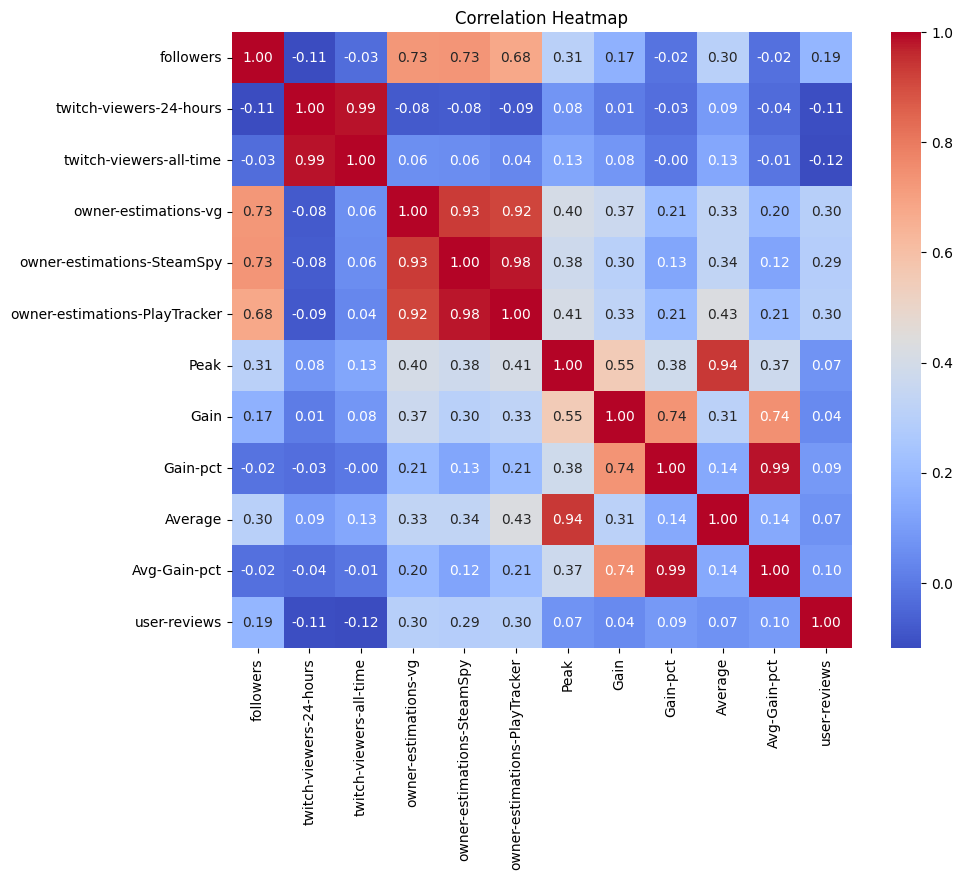

In [77]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(df_int.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [78]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import numpy as np

try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    xgb_available = False

# Target and features (adjust 'posReviews' to your actual target column if needed)
target_col = 'user-reviews'
features = [col for col in df_int.columns if col != target_col and df_int[col].dtype in [np.int64, np.float64]]

# Prepare dataset sizes
sizes = [1/3, 2/3, 1.0]
results = []

for size in sizes:
    n = int(len(df_int) * size)
    X = df_int[features].iloc[:n].fillna(0)
    y = df_int[target_col].iloc[:n].fillna(0)
    X_train, X_test, y_train, y_test = X, X, y, y  # Use all for both train/test for fair comparison
    # Linear Regression
    lr = LinearRegression().fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)
    mae_lr = mean_absolute_error(y_test, y_pred_lr)
    rmse_lr = root_mean_squared_error(y_test, y_pred_lr)
    results.append({'Model': 'LinearRegression', 'Size': n, 'MAE': mae_lr, 'RMSE': rmse_lr})
    # Random Forest
    rf = RandomForestRegressor(random_state=42).fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    mae_rf = mean_absolute_error(y_test, y_pred_rf)
    rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
    results.append({'Model': 'RandomForest', 'Size': n, 'MAE': mae_rf, 'RMSE': rmse_rf})
    # XGBoost (if available)
    if xgb_available:
        xgb = XGBRegressor(random_state=42).fit(X_train, y_train)
        y_pred_xgb = xgb.predict(X_test)
        mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
        rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)
        results.append({'Model': 'XGBoost', 'Size': n, 'MAE': mae_xgb, 'RMSE': rmse_xgb})

results_df = pd.DataFrame(results)
results_df

,Model,Size,MAE,RMSE
0,LinearRegression,30,10.617049,15.840386
1,RandomForest,30,5.482333,8.328033
2,LinearRegression,60,16.344439,21.636287
3,RandomForest,60,5.689667,7.923737
4,LinearRegression,91,17.596065,22.953474
5,RandomForest,91,4.878571,6.794412
